# Analisi Salariale
**Obiettivo:** Analizzare il dataset dei salari per capire le relazioni tra le variabili e prevedere il salario usando modelli di regressione.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
#from sklearn.linear_model import LinearRegression, Ridge
#from sklearn.metrics import mean_squared_error, r2_score

# Per usare le funzioni della cartella src
import sys
import os
sys.path.append(os.path.abspath("../src"))
from preprocessing import scale_data
from modeling import train_linear_regression, train_ridge_regression
from evaluation import evaluate_regression_model
from plots import plot_salary_distribution, plot_correlation_matrix, plot_distribution, plot_predicted_vs_actual, plot_residuals

ImportError: cannot import name 'plot_salary_distribution' from 'plots' (c:\Users\mario\salary-prediction-analysis\notebooks\plots.py)

In [ ]:
df = pd.read_csv("../data/raw/salary_prediction_data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


# Pulizia dei Dati

## Valori mancanti
Vediamo se ci sono valori nulli o assenti nel dataset.

In [ ]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

Notiamo che ogni colonna ha 2 valori mancanti, quindi procediamo a risolvere questi problemi. Andiamo ad estrarre le righe del dataset corrispondenti ai valori mancanti

In [ ]:
df[df.isnull().any(axis=1)] # axis=1 scorre le righe e vede se in qualche colonna c'è un valore mancante

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
172,NaN,NaN,NaN,NaN,NaN,NaN
260,NaN,NaN,NaN,NaN,NaN,NaN


Notiamo che i valori mancanti corrispondono a due righe specifiche in cui non abbiamo informazioni, per cui eliminiamole dal nostro Dataset

In [ ]:
# Metodo 1
# df = df.dropna()

# Metodo 2
df = df[~df.isnull().any(axis=1)]

Controlliamo ora se il nostro se ci sono ancora dei dati mancanti

In [ ]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

A questo punto possiamo quindi salvare il nostro dataset pulito in un nuovo file csv

In [ ]:
df.to_csv("C:/Users/mario/salary-prediction-analysis/data/processed/clean_df.csv", index=False)

# Analisi Esplorativa dei Dati (EDA)
In questa sezione esploreremo il dataset per capire la distribuzione delle variabili, la presenza di valori mancanti e le relazioni tra le feature e il salario.

In [ ]:
df = pd.read_csv("C:/Users/mario/salary-prediction-analysis/data/processed/clean_df.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


## Struttura del dataset
Verifichiamo il numero di righe, colonne e tipi di dati.

In [ ]:
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    str    
 2   Education Level      373 non-null    str    
 3   Job Title            373 non-null    str    
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), str(3)
memory usage: 17.6 KB


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
count,373.000000,373,373,373,373.000000,373.000000
unique,NaN,2,3,174,NaN,NaN
top,NaN,Male,Bachelor's,Director of Marketing,NaN,NaN
freq,NaN,194,224,12,NaN,NaN
mean,37.431635,NaN,NaN,NaN,10.030831,100577.345845
std,7.069073,NaN,NaN,NaN,6.557007,48240.013482
min,23.000000,NaN,NaN,NaN,0.000000,350.000000
25%,31.000000,NaN,NaN,NaN,4.000000,55000.000000
50%,36.000000,NaN,NaN,NaN,9.000000,95000.000000
75%,44.000000,NaN,NaN,NaN,15.000000,140000.000000


## Distribuzione del salario
Analizziamo come sono distribuiti i salari nel dataset.

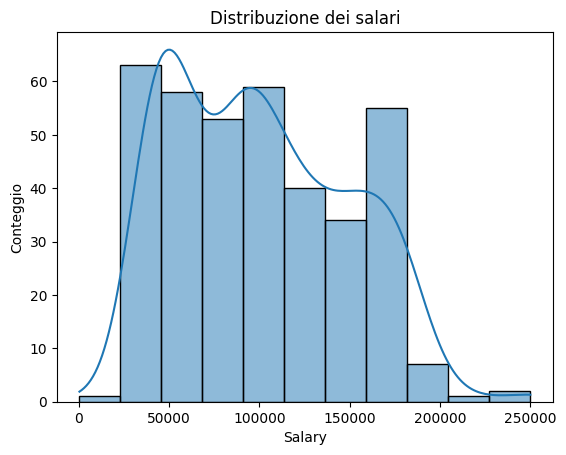

In [ ]:
plot_salary_distribution(df, "Salary")

Notiamo che:
- La distribuzione dei salari non è simmetrica e ha più punti di massimo
- Questo suggerisce che è composta da più sottogruppi con distribuzioni diverse

## Correlazioni tra variabili numeriche
Controlliamo quali variabili numeriche sono più correlate con il salario usando la correlazione di Pearson.

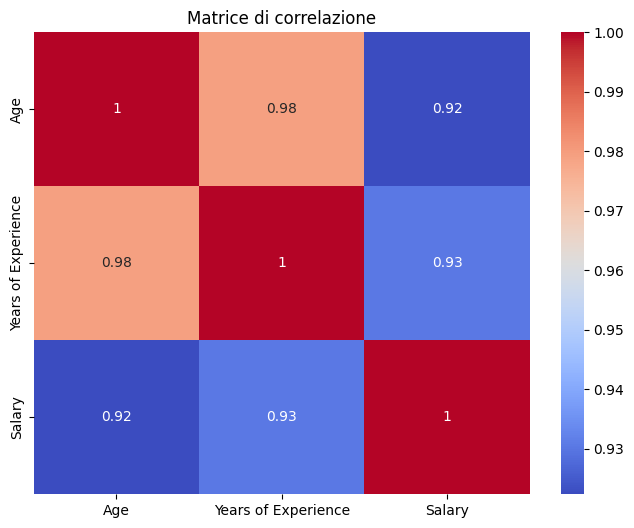

In [ ]:
numeric_cols = df._get_numeric_data()
plot_correlation_matrix(numeric_cols)

Per avere certezze del coefficiente di correlazione di Pearson, andiamo a calcolare anche il **p-value**

#### "Age" - "Salary"

In [ ]:
from scipy import stats
pearson_coef, p_value = stats.pearsonr(df["Age"], df["Salary"])
print("Pearson Correlation:", pearson_coef.round(2))
print("P-value:", p_value)

Pearson Correlation: 0.92
P-value: 2.7461207723240693e-155


#### "Years of Experience" - "Salary"

In [ ]:
from scipy import stats
pearson_coef, p_value = stats.pearsonr(df["Years of Experience"], df["Salary"])
print("Pearson Correlation:", pearson_coef.round(2))
print("P-value:", p_value)

Pearson Correlation: 0.93
P-value: 1.0213700949589796e-163


In entrambi i casi la correlazione è molto forte e positiva, e il p-value molto piccolo indica che è statisticamente significativa.

Per vederlo anche graficamente, andiamo a costruire i regplot

<function matplotlib.pyplot.show(close=None, block=None)>

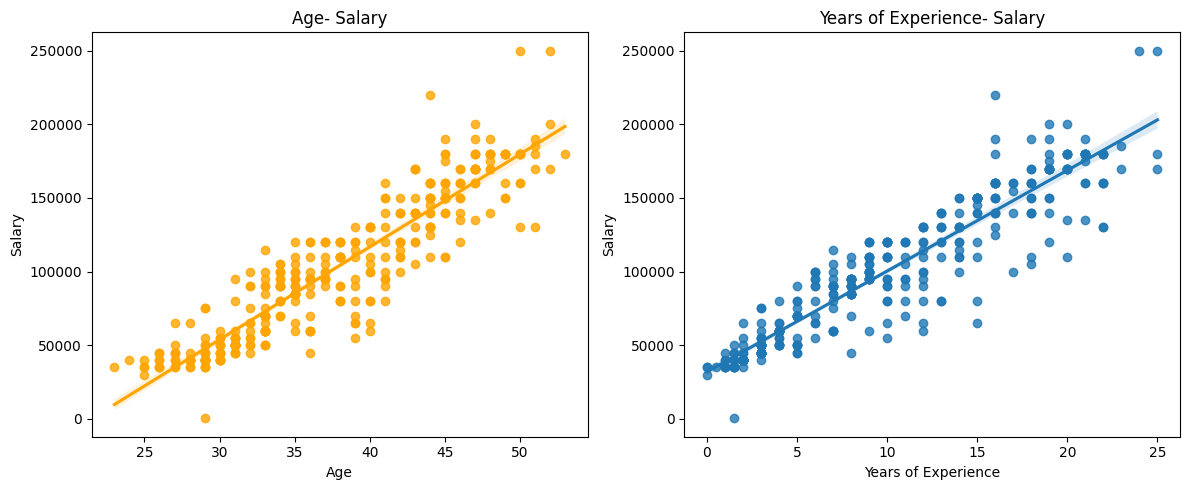

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(12, 5))

sns.regplot(data=df, x="Age", y="Salary", ax=ax[0], color="orange")
ax[0].set_title("Age- Salary")

sns.regplot(data=df, x="Years of Experience", y="Salary", ax=ax[1])
ax[1].set_title("Years of Experience- Salary")

plt.tight_layout()
plt.show

## Analisi delle variabili categoriche
Vediamo come le variabili categoriali (es. Education Level, Job Title, Gender) influenzano il salario.

#### "Education Level" - "Salary"

Education Level
Bachelor's    224
Master's       98
PhD            51
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

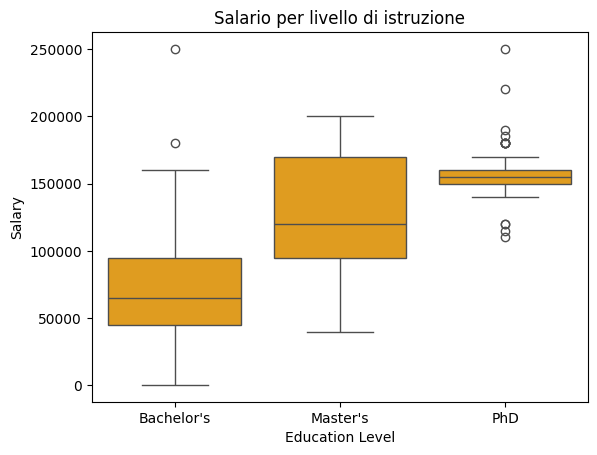

In [ ]:
# Controllo frequenze
print(df['Education Level'].value_counts())

# Boxplot per capire la relazione con il salario
sns.boxplot(x='Education Level', y='Salary', data=df, color="orange")
plt.title("Salario per livello di istruzione")
plt.show

Vediamo che le due categorie Bachelor's e PhD hanno degli outliers, quindi individuiamoli utilizzando il **metodo IQR**.

In [ ]:
# Lista per salvare gli outlier
outliers = pd.DataFrame()

# Itera su ogni livello di istruzione
for level in df['Education Level'].unique():
    salaries = df[df['Education Level'] == level]['Salary']
    Q1 = salaries.quantile(0.25)
    Q3 = salaries.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Seleziona gli outlier per questo livello
    outliers_level = df[(df['Education Level'] == level) & 
                        ((df['Salary'] < lower_bound) | (df['Salary'] > upper_bound))]
    
    outliers = pd.concat([outliers, outliers_level])

# Visualizza gli outlier trovati
print(outliers["Education Level"].value_counts(), "\n")
print(outliers)

Education Level
PhD           14
Bachelor's     2
Name: count, dtype: int64 

      Age  Gender Education Level                        Job Title  \
19   51.0    Male      Bachelor's                   Sales Director   
30   50.0    Male      Bachelor's                              CEO   
9    38.0    Male             PhD                 Senior Scientist   
17   39.0    Male             PhD                  Senior Engineer   
48   38.0    Male             PhD                 Senior Scientist   
63   47.0    Male             PhD            Senior Data Scientist   
72   45.0    Male             PhD                Research Director   
83   52.0    Male             PhD         Chief Technology Officer   
90   36.0    Male             PhD              Principal Scientist   
105  44.0    Male             PhD               Chief Data Officer   
158  51.0  Female             PhD      Director of Human Resources   
187  50.0  Female             PhD  Director of Sales and Marketing   
216  50.0  F

- Più alto il livello di istruzione, più alto tende a essere il salario mediano.
- La variabilità del salario è maggiore per i Master's e Bachelor's rispetto ai PhD.
- Ci sono outlier evidenti, soprattutto nei Bachelor's e PhD, quindi alcuni salari estremi influenzano la distribuzione.

--> Dunque l’**istruzione** è una variabile importante per predire il salario.

Calcoliamo per ogni "Educational level" la media, la mediana e la deviazione standard.

In [ ]:
df_group = df[["Education Level", "Salary"]]
df_group = df_group.groupby(["Education Level"], as_index=False).agg(['mean','median','std'])
print(df_group)

  Education Level         Salary                        
                            mean    median           std
0      Bachelor's   74756.026786   65000.0  34777.272704
1        Master's  129795.918367  120000.0  41659.631919
2             PhD  157843.137255  155000.0  23393.479903


Da questa analisi vediamo che anche se la categoria dei PhD ha più outliers, in realtà **la media è circa uguale alla mediana** e la std è bassa, quindi quseto gruppo è stabile e abbastanza simmetrico, cioè i dati sono bilanciati.

Invece nel caso dei Master's abbiamo che la **media>mediana**, quindi ci sono pochi valori grandi che però influenzano molto la media. Inoltre la std è alta, quindi il gruppo è molto variabile e i dati sono dispersi. Per vederlo facciamo il grafico delle distribuzioni dei salari rispetto ai livelli di istruzione.

<function matplotlib.pyplot.show(close=None, block=None)>

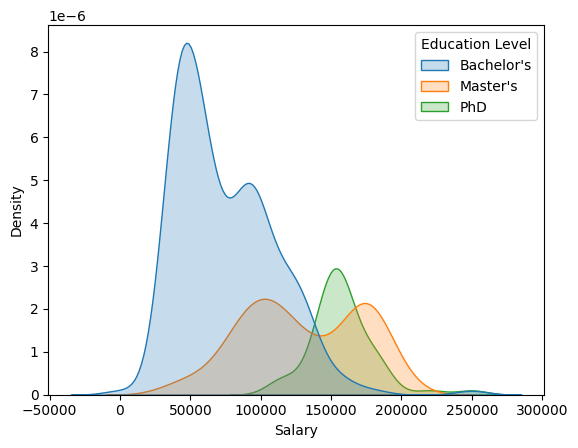

In [ ]:
sns.kdeplot(data=df, x="Salary", hue="Education Level", fill=True)
plt.show

#### "Gender" - "Salary"

Gender
Male      194
Female    179
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

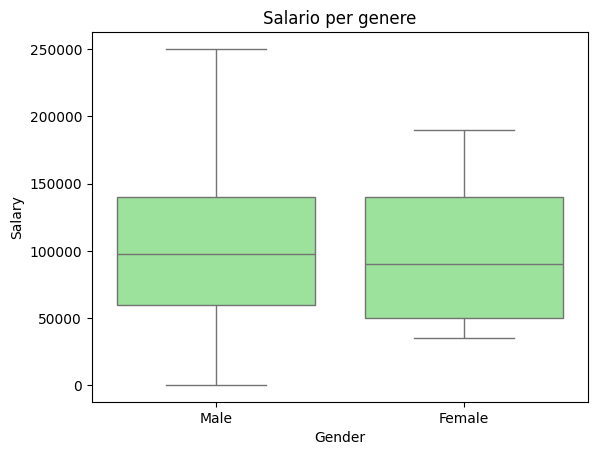

In [ ]:
# Controllo frequenze
print(df['Gender'].value_counts())

# Boxplot per capire la relazione con il salario
sns.boxplot(x='Gender', y='Salary', data=df, color="lightgreen")
plt.title("Salario per genere")
plt.show

Da questo grafico vediamo che:
- La mediana degli uomo è leggermente più alta rispetto alle donne
- Gli uomini mostrano valori massimi più elevati 
- Le distribuzion si sovrappongono molto, non c'è una separazione netta
--> non possiamo quindi dire che gli uomini guadagnano di più o se c'è un gender gap solo con questi dati, perché potrebbero esserci fattori nascosti come il ruolo, l'esprerienza...

In [ ]:
#sns.boxplot(data=df, x="Education Level", y="Salary", hue="Gender")

#### "Job Title" - "Salary"
Infine andiamo a studiare la relazione tra "Job Title" e "Salary". Poiché abbiamo molti lavori diversi, andiamo innanzitutto a calcolare la **media per ogni titolo lavorativo**. Tuttavia poiché potrebbe capitare che ci sia una sola persona con un certo lavoro, per studiare la media, andiamo a considerare i casi in cui ci sono almeno 5 persone con lo stesso titolo.

In [ ]:
counts = df["Job Title"].value_counts()
valid_jobs = counts[counts >= 5].index

df_filtrato = df[df["Job Title"].isin(valid_jobs)]

df_filtrato.groupby("Job Title")["Salary"].mean().sort_values(ascending=False)

Job Title
Director of Marketing                    175833.333333
Director of Operations                   172727.272727
Senior Data Scientist                    160000.000000
Senior Product Designer                  148000.000000
Senior Project Manager                   129285.714286
Senior Marketing Manager                 127222.222222
Senior Product Manager                   121666.666667
Senior Software Engineer                 120833.333333
Senior Business Analyst                  116000.000000
Senior Financial Analyst                 112857.142857
Senior Operations Manager                108000.000000
Senior Financial Manager                 100000.000000
Senior Project Coordinator                92000.000000
Senior Marketing Analyst                  89444.444444
Junior Marketing Specialist               53000.000000
Junior Financial Analyst                  52857.142857
Junior Operations Analyst                 51000.000000
Junior Business Analyst                   50000.000000


Quello che possiamo affermare è che i salari aumentano con la seniority implicita nel job title

## Sviluppo del modello

In [ ]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


#### Preparazione dei dati
La nostra variabile target è il "Salary", mentre come variabili predictor andiamo a considerare "Age", "Years of Experience" e l'"Education Level"

In [ ]:
df_encoded = pd.get_dummies(df, columns=["Gender", "Education Level"], drop_first=True)

X = df_encoded.drop(["Salary","Job Title"], axis=1)
Y = df["Salary"]

# Separiamo le variabili di training da quelle di test (80% training data - 20% test data)
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

#### Modello di Regressione Lineare Multipla
Andiamo ad addestrare un modello di regressione lineare multipla
 $$\hat{y} = b_0 + b_1 x_1 + b_2 x_2 + b_3 x_3 + \ldots $$

In [ ]:
mlr = train_linear_regression(x_train, y_train)
y_pred_train = mlr.predict(x_train)
y_pred_test = mlr.predict(x_test)


## Validazione del modello attraverso le metriche

#### $R^2$

In [ ]:
r2_train = mlr.score(x_train,y_train)
print("L'R^2 dei training test è:", r2_train, "\n")

r2_test = mlr.score(x_test, y_test)
print("L'R^2 dei data test è:", r2_test)

L'R^2 dei training test è: 0.9014091547262573 

L'R^2 dei data test è: 0.903302221764233


Dall'R^2 possiamo dire che il modello ha:
- buona capacità predittiva
- generalizzazione discreta
- no overfitting evidente

#### MAE (Mean Absolute Error) e RMSE (Root Mean Squared Error)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 10599.92156230598
RMSE: 15226.321749735282


Il MAE rappresenta l'errore medio in valore assoluto, quindi risponde alla domanda "in media, quanto sbaglio?" --> Nel nostro caso il modello sbaglia mediamenti di circa 10.500 euro

Il RMSE rappresenta la radice quandrata dell'errore quadratico medio e **penalizza molto gli errori grandi** --> Nel nostro caso RMSE $\simeq 15.000$, per cui gli errori grandi pesano abbastanza.

Poiché RMSE > MAE vuol dire che ci sono alcuni errori grandi (probabilmente nei salari alti)

## Analisi Grafica

#### Distribuzioni (KDE)

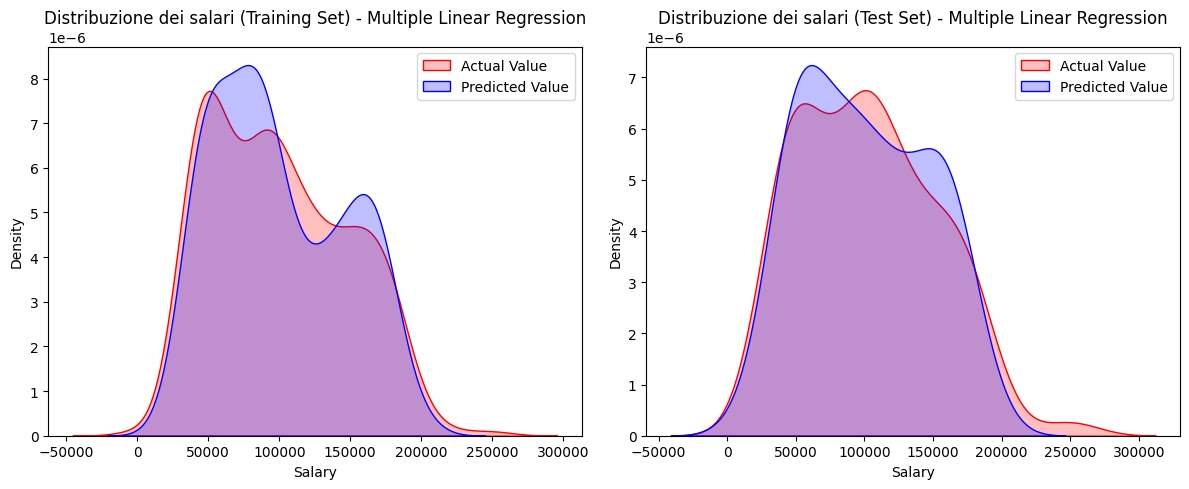

In [ ]:
plot_distribution(y_train, y_pred_train, y_test, y_pred_test, "Multiple Linear Regression", save_path="../results/figures/kde_mlr.png")


Il confronto tra le distribuzioni dei salari reali e predetti mostra una buona sovrapposizione sia nel training set che nel test set, indicando che il modello è in grado di riprodurre la struttura globale del target. Tuttavia, si osserva una leggera differenza nelle code della distribuzione, con il modello che tende a smussare la variabilità e a sottostimare i valori estremi, in particolare per salari elevati. Questo ci permette di dire che il modello cattura bene il trend medio, ma perde precisione nelle fasce più alte.

#### Scatter Plot

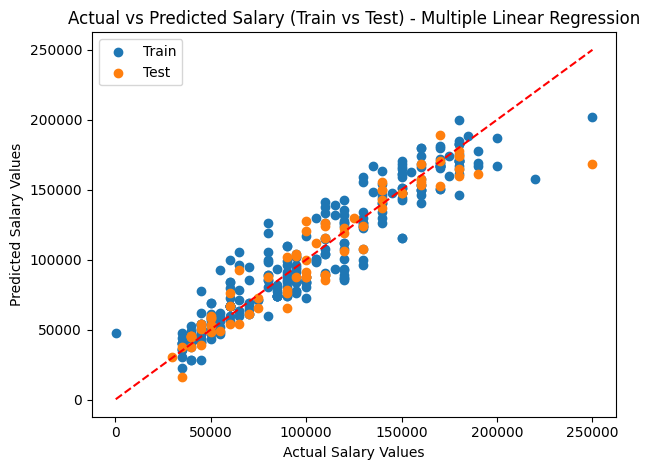

In [ ]:
plot_predicted_vs_actual(y_train, y_pred_train, y_test, y_pred_test, "Multiple Linear Regression", save_path="../results/figures/predictions_mlr.png")

Da questo grafico possiamo dedurre che:
- le predizioni seguono abbastanza bene i valori reali
- il modello cattura la struttura il trend generale del fenomeno

#### Residual Plot

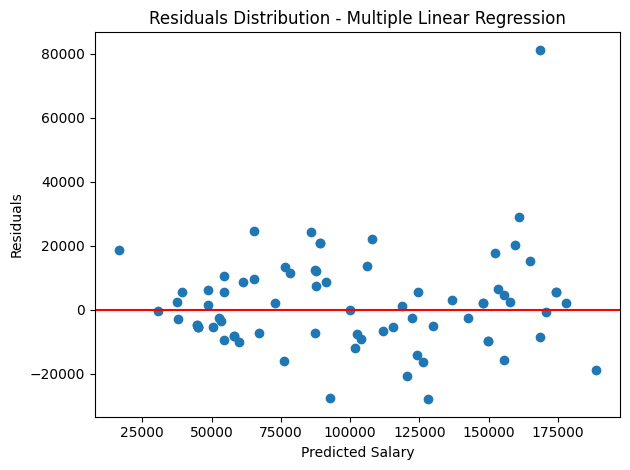

In [ ]:
plot_residuals(y_test, y_pred_test, "Multiple Linear Regression", save_path="../results/figures/residuals_mlr.png")

Il grafico mostra che i punti sono:
- centrati intorno a 0
- abbastanza sparsi
--> quindi il modello non ha un bias evidente (non sovrastima sempre o sottostima sempre)

Notiamo però che:
- per salari bassi abbiamo errori più piccoli e punti abbastanza vicini allo 0
- per salari alti l'errore è più grande e la dispersione aumenta. 

Questo fenomeno è detto **ETEROSCHEDASTICITÀ** e in particolare possiamo dire che il modello è più debole proprio dove i salari sono più alti, cioè dove probabilmente la struttura retributiva è più complessa e meno lineare.

## Conclusioni Analisi 1
Il modello di regressione lineare multipla mostra una buona capacità predittiva, con un valore di R² pari a circa 0.91 sul training set e 0.903 sul test set, indicando una discreta generalizzazione e l’assenza di overfitting evidente.

Le metriche di errore forniscono una misura più concreta delle prestazioni del modello: il Mean Absolute Error (MAE) risulta pari a circa 10.600€, indicando che il modello commette in media un errore di questa entità nelle predizioni, mentre il Root Mean Squared Error (RMSE), pari a circa 15.226€, evidenzia la presenza di errori più rilevanti su alcune osservazioni.

L’analisi grafica mostra che il modello è in grado di catturare il trend generale del fenomeno e di riprodurre la distribuzione complessiva dei salari, sia nel training set che nel test set. Tuttavia, il confronto tra valori reali e predetti evidenzia una dispersione crescente per salari più elevati.

Il grafico dei residui conferma questa osservazione, mostrando una varianza non costante degli errori (eteroschedasticità): il modello risulta più accurato per salari bassi e medi, mentre perde precisione nelle fasce più alte.

Questo comportamento suggerisce che il modello, pur funzionando bene in media, non riesce a catturare completamente la complessità del fenomeno, probabilmente a causa dell’assenza di variabili rilevanti come il ruolo lavorativo (Job Title).

In conclusione, il modello rappresenta una buona base per la previsione del salario, ma presenta limiti strutturali che rendono necessaria una fase di miglioramento, in particolare per gestire meglio la variabilità nelle fasce salariali più elevate.

## Analisi 2 - primo tentativo di miglioramento
Poiché nel modello base abbiamo osservato una buona capacità predittiva, ma i residui mostravano eteroschedasticità, vogliamo provare ad effettuare una **trasformazione logaritmica** del target Salary. 

**Obiettivo:** rendere più stabile il modello e ridurre l'influenza dei salari molto alti

In [ ]:
# 1. Nuovo target
df["log_salary"] = np.log(df["Salary"])

# 2. Encoding
df_encoded = pd.get_dummies(df, columns=["Gender", "Education Level"], drop_first=True)

# 3. Feature e target
X = df_encoded.drop(["Salary", "log_salary", "Job Title"], axis=1)
Y = df_encoded["log_salary"]

# 4. Split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 5. Modello
model_log = train_linear_regression(x_train, y_train) 

# 6. Predizioni in log
y_pred_train_log = model_log.predict(x_train)
y_pred_test_log = model_log.predict(x_test)

# 7. Torniamo in euro
y_train_exp = np.exp(y_train)
y_test_exp = np.exp(y_test)
y_pred_train_exp = np.exp(y_pred_train_log)
y_pred_test_exp = np.exp(y_pred_test_log)

# 8. Metriche
r2_train_log = model_log.score(x_train, y_train)
r2_test_log = model_log.score(x_test, y_test)

mae_log_model = mean_absolute_error(y_test_exp, y_pred_test_exp)
rmse_log_model = np.sqrt(mean_squared_error(y_test_exp, y_pred_test_exp))

print("R² train (log):", r2_train_log)
print("R² test (log):", r2_test_log)
print("MAE:", mae_log_model)
print("RMSE:", rmse_log_model)

R² train (log): 0.6826223369097387
R² test (log): 0.889398570124204
MAE: 13569.237094115271
RMSE: 18584.859529509566


### Analisi grafica


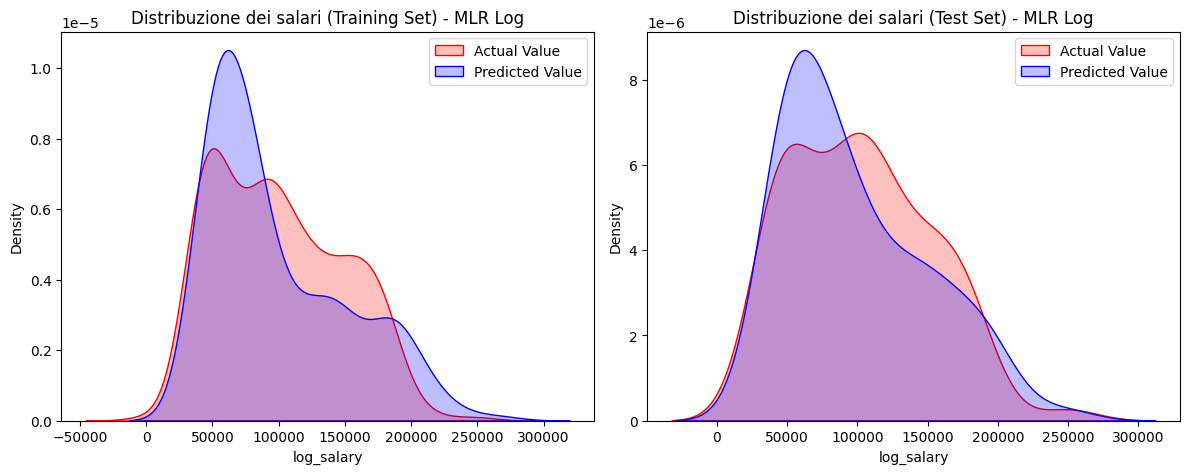

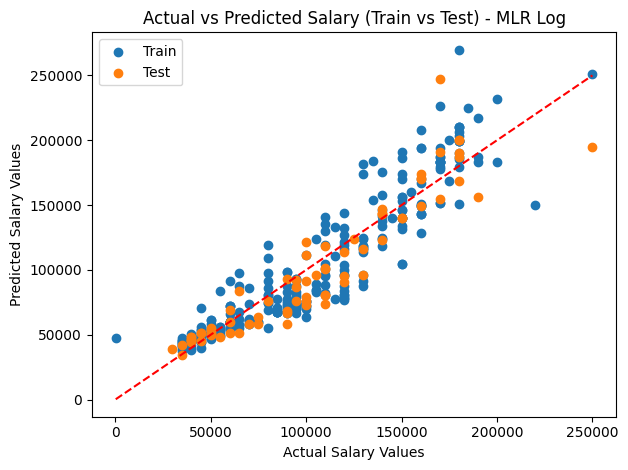

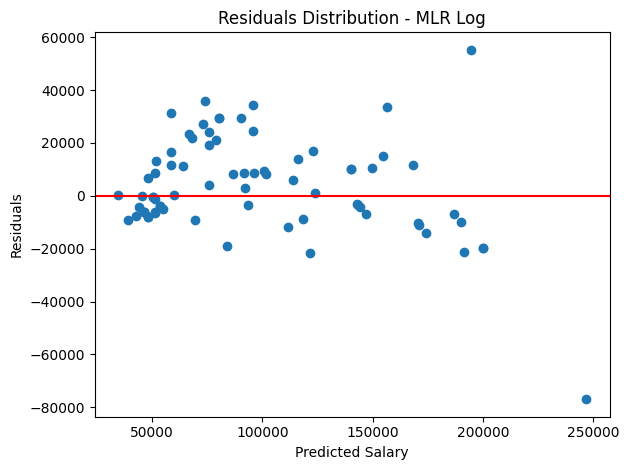

In [ ]:
plot_distribution(y_train_exp, y_pred_train_exp, y_test_exp, y_pred_test_exp, "MLR Log")
plot_predicted_vs_actual(y_train_exp, y_pred_train_exp, y_test_exp, y_pred_test_exp, "MLR Log")
plot_residuals(y_test_exp, y_pred_test_exp, "MLR Log")


### Conclusioni Analisi 2
La trasformazione logaritmica della variabile target è stata introdotta per ridurre l’asimmetria della distribuzione dei salari e rendere più plausibile l’ipotesi di relazione lineare tra le variabili esplicative e il target.

Dal punto di vista del fit sul training set, il modello logaritmico mostra un valore di $R^2$ inferiore rispetto al modello base, indicando una minore capacità di adattarsi ai dati di training. Sul test set, le prestazioni risultano leggermente inferiori o comunque non migliorative rispetto al modello senza trasformazione.

È importante sottolineare che il confronto diretto tra i valori di $R^2$ dei due modelli non è del tutto omogeneo, poiché uno è calcolato sulla scala originale dei salari, mentre l’altro sulla scala logaritmica. Inoltre, la riconversione delle predizioni tramite esponenziale può introdurre un bias sistematico.

Nel complesso, la trasformazione logaritmica non porta a un miglioramento evidente delle prestazioni predittive nella scala originale del problema. Tuttavia, può comunque risultare utile per motivi diagnostici, ad esempio per ottenere residui più regolari o attenuare l’influenza di valori estremi.

## Analisi 3 - secondo tentativo di miglioramento (Inserimento Job Title)

Nei modelli precedenti il ruolo lavorativo non era stato incluso tra i predictor. Tuttavia, è plausibile che il Job Title influenzi in modo significativo il salario. Per questo motivo, in questa terza analisi introduciamo anche questa variabile, con l’obiettivo di migliorare la capacità esplicativa e predittiva del modello.

In [ ]:
df.drop(["log_salary"], axis=1, inplace=True)
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


R² train: 0.9832156611904972
R² test: 0.8522475952130937
MAE: 11596.521058222643
RMSE: 18821.491412947813


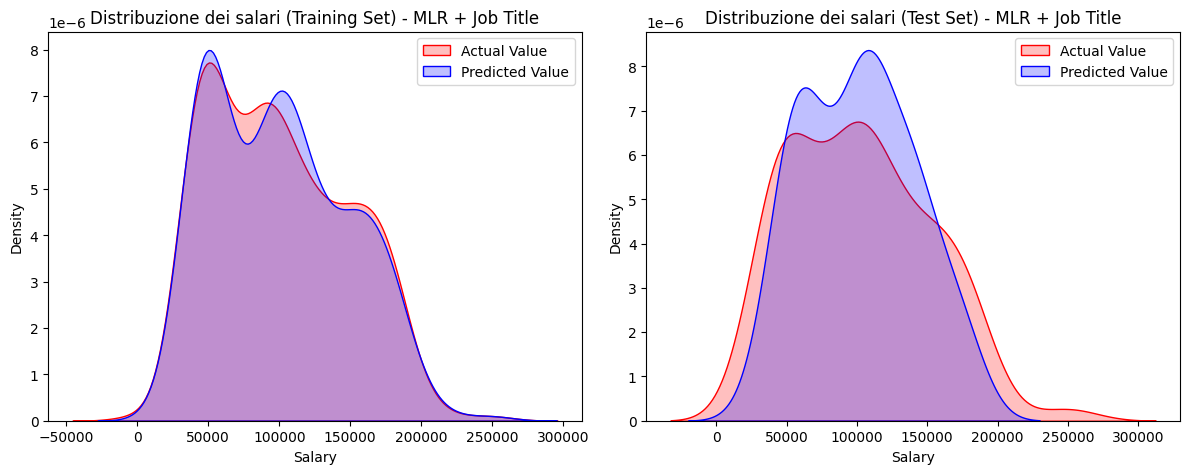

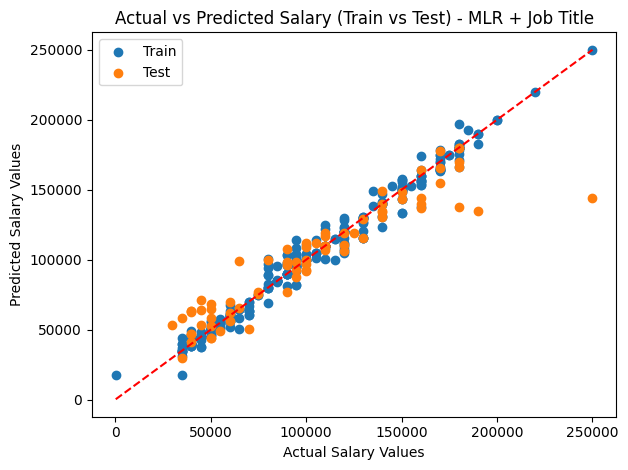

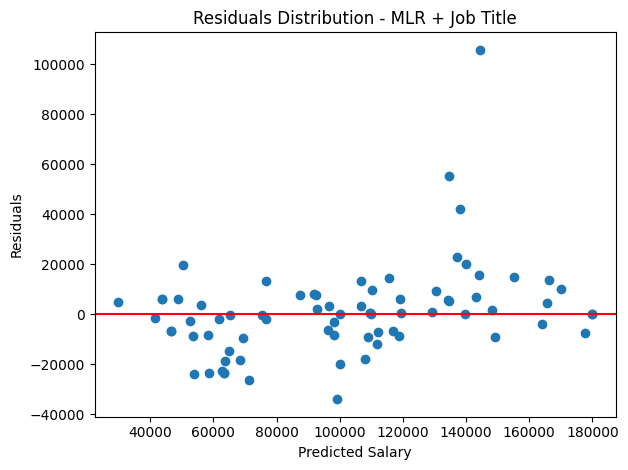

         Modello   R2_test           MAE          RMSE
0           Base  0.903302  10599.921562  15226.321750
1    Log(Salary)  0.889399  13569.237094  18584.859530
2  Con Job Title  0.852248  11596.521058  18821.491413


In [ ]:
# 1. Encoding
df_encoded = pd.get_dummies(df, ["Gender", "Education Level", "Job Title"], drop_first = True)

# 2. Features e Target
X = df_encoded.drop(["Salary"], axis=1)
Y= df_encoded["Salary"]

# 3. Train/Test split
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

# 4. Modello di Regressione Lineare
model_job = train_linear_regression(x_train, y_train)

# 5. Predizioni
y_pred_train_job = model_job.predict(x_train)
y_pred_test_job = model_job.predict(x_test)

# 6. Metriche
r2_train_job = model_job.score(x_train, y_train)
results_job = evaluate_regression_model(model_job, x_test, y_test)

print("R² train:", r2_train_job)
print("R² test:", results_job["r2"])
print("MAE:", results_job["mae"])
print("RMSE:", results_job["rmse"])

# 7. Analisi Grafica
plot_distribution(y_train, y_pred_train_job, y_test, y_pred_test_job, "MLR + Job Title")
plot_predicted_vs_actual(y_train, y_pred_train_job, y_test, y_pred_test_job, "MLR + Job Title")
plot_residuals(y_test, y_pred_test_job, "MLR + Job Title")

# 8. Confronto
confronto = pd.DataFrame({
    "Modello": [
        "Base",
        "Log(Salary)",
        "Con Job Title"
    ],
    "R2_test": [
        r2_test,
        r2_test_log,
        results_job["r2"]
    ],
    "MAE": [
        mae,
        mae_log_model,
        results_job["mae"]
    ],
    "RMSE": [
        rmse,
        rmse_log_model,
        results_job["rmse"]
    ]
})

print(confronto)

### Conclusioni Analisi 3 
L’inclusione della variabile Job Title, codificata tramite variabili dummy, consente al modello di catturare informazioni aggiuntive legate al ruolo professionale, che risultano plausibilmente rilevanti per la determinazione del salario.

Infatti, il modello mostra un valore di $R^2$ molto elevato sul training set, segno di una forte capacità di adattamento ai dati osservati. Tuttavia, questa performance non si traduce in un analogo miglioramento sul test set, dove si osserva una diminuzione significativa delle prestazioni rispetto al training.

Questo divario tra training e test è indicativo di un fenomeno di overfitting: il modello tende a “memorizzare” le specificità dei job title presenti nel training set, perdendo capacità di generalizzazione su dati nuovi. Il problema è plausibilmente accentuato dall’elevata cardinalità della variabile Job Title, che introduce un gran numero di parametri.

Pertanto, sebbene la variabile contenga informazione utile, il suo utilizzo diretto tramite one-hot encoding risulta poco robusto. Questo suggerisce la necessità di approcci alternativi, come tecniche di regolarizzazione (ad esempio Ridge), aggregazione delle categorie o metodi di encoding più strutturati.

## Analisi 4 - terzo tentativo di miglioramento (Ridge Regression)

Dato che dall'analisi precedente ci troviamo di fronte ad un fenomeno di overfitting dovuto al fatto che il modello lineare con dummy crea tantissime variabili e ola stima sui coefficienti risulta instabile, possiamo provare a migliorare il modello utilizzando la regressione Ridge, ovvero il processo di regolarizzazione del set di caratteristiche tramite l'iperparametro alfa.

Per determinare il miglior iperparametro alpha, utilizziamo la **Grid Search**

Il miglior iperparametro alpha è: {'alpha': 1}
R^2 train: 0.963448846487535
R^2 test: 0.905084039126154
MAE: 9622.792588453993
RMSE: 15085.384330413108


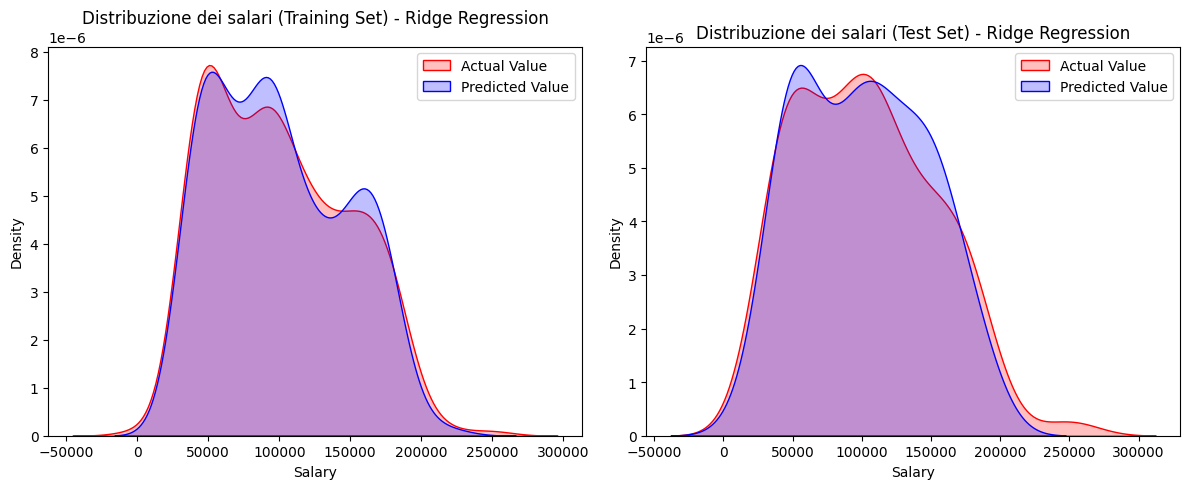

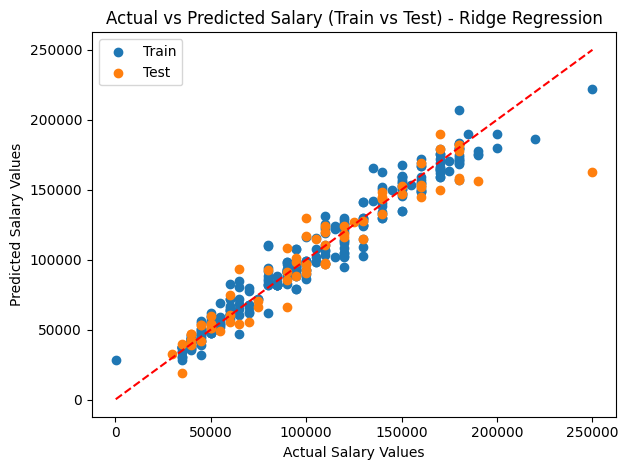

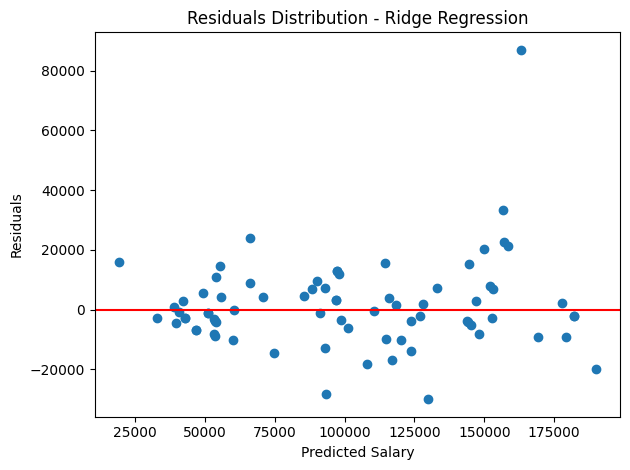

         Modello   R2_test           MAE          RMSE
0           Base  0.903302  10599.921562  15226.321750
1    Log(Salary)  0.889399  13569.237094  18584.859530
2  Con Job Title  0.852248  11596.521058  18821.491413
3          Ridge  0.905084   9622.792588  15085.384330


In [ ]:
from sklearn.model_selection import GridSearchCV

# 1. Encoding
df_encoded = pd.get_dummies(df, ["Gender", "Education Level", "Job Title"], drop_first = True)

# 2. Features e Target
X = df_encoded.drop(["Salary"], axis=1)
Y= df_encoded["Salary"]

# 3. Train/Test split
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.2, random_state=42)

# 4. Modello Ridge
Ridge = train_ridge_regression(x_train, y_train)

# 5. Predizioni
y_pred_train_Ridge = Ridge.predict(x_train)
y_pred_test_Ridge = Ridge.predict(x_test)

# 6. Metriche
r2_train_Ridge = Ridge.score(x_train,y_train)
results_Ridge = evaluate_regression_model(Ridge, x_test, y_test)

print("R^2 train:", r2_train_Ridge)
print("R^2 test:", results_Ridge["r2"])
print("MAE:", results_Ridge["mae"])
print("RMSE:", results_Ridge["rmse"])

# 7. Analisi Grafica
plot_distribution(y_train, y_pred_train_Ridge, y_test, y_pred_test_Ridge, "Ridge Regression", save_path="../results/figures/kde_Ridge.png")
plot_predicted_vs_actual(y_train, y_pred_train_Ridge, y_test, y_pred_test_Ridge, "Ridge Regression", save_path="../results/figures/preditions_Ridge.png")
plot_residuals(y_test, y_pred_test_Ridge, "Ridge Regression", save_path="../results/figures/residuals_Ridge.png")

# 8. Confronto
confronto = pd.DataFrame({
    "Modello": [
        "Base",
        "Log(Salary)",
        "Con Job Title",
        "Ridge"
    ],
    "R2_test": [
        r2_test,
        r2_test_log,
        results_job["r2"],
        results_Ridge["r2"]
    ],
    "MAE": [
        mae,
        mae_log_model,
        results_job["mae"],
        results_Ridge["mae"]
    ],
    "RMSE": [
        rmse,
        rmse_log_model,
        results_job["rmse"],
        results_Ridge["rmse"]
    ]
})

print(confronto)


### Conclusioni Analisi 4
L’introduzione della regressione Ridge ha permesso di migliorare significativamente le prestazioni del modello rispetto ai tentativi precedenti.

A differenza del modello lineare con encoding diretto della variabile “Job Title”, che mostrava fenomeni di overfitting, la Ridge Regression introduce una penalizzazione sui coefficienti che riduce la complessità del modello e ne migliora la capacità di generalizzazione.

I risultati quantitativi mostrano un miglioramento in tutte le metriche: il coefficiente R² sul test set risulta leggermente superiore rispetto al modello base, mentre MAE e RMSE risultano più bassi, indicando una riduzione dell’errore medio e degli errori più grandi.

L’analisi grafica conferma questi risultati, evidenziando una maggiore aderenza tra valori reali e predetti e una riduzione della dispersione dei residui.

Tuttavia, si osserva ancora una lieve eteroschedasticità, suggerendo che il modello potrebbe essere ulteriormente migliorato attraverso trasformazioni del target o modelli non lineari.

In conclusione, la Ridge Regression rappresenta il miglior compromesso tra capacità predittiva e generalizzazione tra i modelli analizzati.